# Lesson 11 — From Resonance Absorption to Neutron Thermalization

**Builds on:** [Lesson 10](lesson_10.ipynb).
**Seed:** [`xfnrp/Chapter3/NeutronThermalization.ipynb`](../../xfnrp/Chapter3/NeutronThermalization.ipynb).

By the end of this lesson, you should be able to:

1. Extend the Lesson 10 uranium–water calculation below 1 eV without killing thermal neutrons.
2. Explain upscatter, detailed balance, and the role of an $S(\alpha,\beta)$ scattering law.
3. Compare the computed thermal **flux** with $E\exp[-E/(k_BT)]$.
4. Separate temperature effects, absorption-induced hardening, and plotting normalization.

**Draft for instructor review.** Select a Python kernel containing OpenMC,
NumPy, pandas, and Matplotlib. The OpenMC executable and a continuous-energy
neutron-data library, including `c_H_in_H2O`, must be available. Activate your
OpenMC environment before launching Jupyter; its `OPENMC_CROSS_SECTIONS`
variable should name `cross_sections.xml`.

This notebook is standalone: it does not execute or modify another lesson.
Runs write XML/HDF5 files only to the scratch directory printed below.
The density is the same pedagogical **1 g/cm³** as Lesson 10; this is a
homogeneous uranium–water mixture, not a heterogeneous fuel lattice or a
chemical-solubility model. Oxygen here belongs to water, not added UO₂.

## 1. What changes from Lesson 10?

Keep the natural-uranium/water material, 1 MeV incident neutrons, and reflective
sphere. Change these specific details:

| Lesson 10 | Lesson 11 |
|---|---|
| Neutrons are terminated below 1 eV | Remove that transport cutoff |
| Resonance-range flux bins | Include the thermal region and the incident source energy |
| Free-atom scattering treatment | Add `c_H_in_H2O` for bound hydrogen in water |
| Arbitrarily scaled flux curve | Report bin-integrated tallies per source neutron, with explicit volume/bin normalization |

For this thermalization experiment, explicitly set
`create_fission_neutrons=False`: the uranium can absorb/fission, but its fission
descendants are not transported. This isolates the response to the specified
1 MeV source. **A fixed-source calculation does not automatically suppress
fission descendants.** Lesson 12 will turn their transport on deliberately.

In [1]:
LESSON = "lesson_11"
from pathlib import Path
import json
import os
import shutil
import sys
import tempfile
import warnings

import openmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Use the active environment's evaluated data, not a machine-specific path.
xs_setting = os.environ.get("OPENMC_CROSS_SECTIONS") or openmc.config.get("cross_sections")
if not xs_setting:
    raise RuntimeError("Activate your OpenMC environment and set OPENMC_CROSS_SECTIONS to cross_sections.xml.")
XS_XML = Path(xs_setting).expanduser().resolve()
if not XS_XML.is_file():
    raise FileNotFoundError(XS_XML)
openmc.config["cross_sections"] = str(XS_XML)
OPENMC_EXE = os.environ.get("OPENMC_EXEC") or shutil.which("openmc")
if not OPENMC_EXE:
    candidate = Path(sys.executable).with_name("openmc")
    if candidate.is_file():
        OPENMC_EXE = str(candidate)
if not OPENMC_EXE:
    raise RuntimeError("The OpenMC executable must be on PATH (or set OPENMC_EXEC).")

library = openmc.data.DataLibrary.from_xml(XS_XML)
for nuclide in ("H1", "O16", "U234", "U235", "U238"):
    if library.get_by_material(nuclide) is None:
        raise RuntimeError(f"Missing neutron data for {nuclide} in {XS_XML}")
if library.get_by_material("c_H_in_H2O", data_type="thermal") is None:
    raise RuntimeError("This lesson needs bound-hydrogen thermal scattering data: c_H_in_H2O.")

TEMPERATURE = 294.0  # K; use a temperature supported by your data library
RADIUS = 1.0         # cm, same reflective sphere as Lesson 10
VOLUME = 4.0 * np.pi * RADIUS**3 / 3.0
K_B = 8.617333262e-5  # eV/K
ENERGY_EDGES = np.geomspace(1e-5, 2e7, 401)  # plotting bins, NOT a transport cutoff
ENERGY = np.sqrt(ENERGY_EDGES[:-1] * ENERGY_EDGES[1:])
DELTA_E = np.diff(ENERGY_EDGES)
DELTA_U = np.log(ENERGY_EDGES[1:] / ENERGY_EDGES[:-1])
THREADS = min(4, os.cpu_count() or 1)
RUN_ROOT = Path(os.environ.get("NE630_RUN_DIR", ".ne630_draft_runs")).resolve() / LESSON
RUN_ROOT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (8, 3.5), "axes.grid": True, "grid.alpha": 0.2})
print(f"OpenMC {openmc.__version__}; {THREADS} threads")
print(f"Cross-section library: {XS_XML}")
print(f"Scratch run directory: {RUN_ROOT}")

OpenMC 0.16.0; 4 threads
Cross-section library: /home/robertsj/opt/openmc/endfb-viii.0-hdf5/cross_sections.xml
Scratch run directory: /home/robertsj/Classes/ne630/review/lesson11-12/executed_runs/lesson_11


## 2. Materials, geometry, and source: the familiar model

Write $R=N_H/N_U$. Using relative atom amounts $(N_H,N_O,N_U)=(R,R/2,1)$
is equivalent to Lesson 10's $(2,1,2/R)$. It avoids confusing **H/U** with
**H₂O/U**, which is $R/2$.

The reflecting boundary eliminates leakage. In a homogeneous material, it
provides an infinite-medium energy-spectrum experiment; the chosen sphere
volume still matters when converting the volume-integrated flux tally into
a volume-average flux. The model factory below repeats Steps 1–3 of Lesson 10.

In [2]:
def make_model(H_to_U=100.0, temperature=TEMPERATURE, bound_hydrogen=True,
               multiplying=False, particles=2000, batches=40, seed=11001):
    """Lesson 10's material/geometry/source, extended through thermal energies.

    H_to_U is N_H / (N_U234 + N_U235 + N_U238), NOT water molecules per U atom.
    H_to_U=None selects pure water. All runs are at the same prescribed density.
    """
    material = openmc.Material(name="water" if H_to_U is None else f"natural U + water, H/U={H_to_U:g}")
    if H_to_U is None:
        material.add_nuclide("H1", 2.0)
        material.add_nuclide("O16", 1.0)
    else:
        if not np.isfinite(H_to_U) or H_to_U <= 0:
            raise ValueError("H_to_U must be positive.")
        material.add_nuclide("H1", float(H_to_U))
        material.add_nuclide("O16", float(H_to_U) / 2.0)
        material.add_element("U", 1.0)  # OpenMC's natural isotopic abundances
    material.set_density("g/cm3", 1.0)
    material.temperature = float(temperature)
    if bound_hydrogen:
        material.add_s_alpha_beta("c_H_in_H2O")

    sphere = openmc.Sphere(r=RADIUS, boundary_type="reflective")
    cell = openmc.Cell(fill=material, region=-sphere)
    settings = openmc.Settings()
    settings.run_mode = "fixed source"
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        energy=openmc.stats.Discrete([1e6], [1.0]),
    )
    settings.particles = int(particles)
    settings.batches = int(batches)
    settings.seed = int(seed)
    settings.create_fission_neutrons = bool(multiplying)
    # Deliberately NO energy_neutron=1 eV cutoff: neutrons must reach the thermal range.
    materials = openmc.Materials([material])
    materials.cross_sections = str(XS_XML)
    model = openmc.Model(geometry=openmc.Geometry([cell]), materials=materials, settings=settings)
    return model, material, cell


def run_openmc(model, label):
    # Every case gets its own directory; rerunning cells cannot mix old/new statepoints.
    case_dir = Path(tempfile.mkdtemp(prefix=label + "-", dir=RUN_ROOT))
    statepoint = model.run(cwd=case_dir, openmc_exec=OPENMC_EXE, threads=THREADS, output=False)
    return Path(statepoint), case_dir

In [3]:
model, material, cell = make_model(H_to_U=100.0)
atom_densities = material.get_nuclide_atom_densities()  # atom/(barn cm)
display(pd.DataFrame({"N [atom/(barn cm)]": atom_densities}))
N_U = sum(value for name, value in atom_densities.items() if name.startswith("U"))
print(f"Actual H/U = {atom_densities['H1'] / N_U:.6g}")
print(f"Natural-U U-235 atom fraction = {atom_densities['U235'] / N_U:.6%}")

,N [atom/(barn cm)]
H1,5.289274e-02
O16,2.644637e-02
U234,2.856208e-08
U235,3.810393e-06
U238,5.250885e-04


Actual H/U = 100
Natural-U U-235 atom fraction = 0.720400%


## 3. Tally and normalize the spectrum correctly

For energy bin $g$, OpenMC's cell-filtered track-length `flux` score is

$$T_{\phi,g}=\frac{1}{N_{\rm source}}\sum_{\text{tracks in }V,g}w\ell.$$

It is already normalized **per source neutron** and integrated over the cell
and energy bin. Thus

$$\bar\phi_g \simeq \frac{T_{\phi,g}}{V\,\Delta E_g},\qquad
\bar\phi_{u,g}=\frac{T_{\phi,g}}{V\,\ln(E_{g+1}/E_g)}\simeq E\bar\phi(E).$$

Do **not** multiply by the number of particles or batches. To specify an
external source strength $Q$ in neutrons/s, multiply these per-source results
by $Q$; only then do the axes acquire a per-second unit. The plotting grid is
not a transport cutoff.

In [4]:
def attach_flux_tally(model, cell):
    tally = openmc.Tally(name="energy flux")
    tally.filters = [openmc.CellFilter(cell), openmc.EnergyFilter(ENERGY_EDGES)]
    tally.scores = ["flux"]
    tally.estimator = "tracklength"
    model.tallies = openmc.Tallies([tally])


def read_flux(model, label):
    sp_path, case_dir = run_openmc(model, label)
    # Reading a statepoint reconstructs IDs already present in the Python model.
    # Suppress only those duplicate-ID notices, not transport/data warnings.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", openmc.IDWarning)
        with openmc.StatePoint(sp_path) as sp:
            tally = sp.get_tally(name="energy flux")
            mean = tally.get_values(scores=["flux"], value="mean").ravel().copy()
            sd = tally.get_values(scores=["flux"], value="std_dev").ravel().copy()
    return {"bin_flux": mean, "bin_sd": sd,
            "phi_E": mean / (VOLUME * DELTA_E),
            "phi_u": mean / (VOLUME * DELTA_U),
            "run_dir": str(case_dir)}


def spectrum_case(label, **kwargs):
    case_model, _, case_cell = make_model(**kwargs)
    attach_flux_tally(case_model, case_cell)
    return read_flux(case_model, label)


attach_flux_tally(model, cell)
reference = read_flux(model, "uranium-water-R100")
print("Reference run complete: 40 batches × 2,000 source neutrons.")

Reference run complete: 40 batches × 2,000 source neutrons.


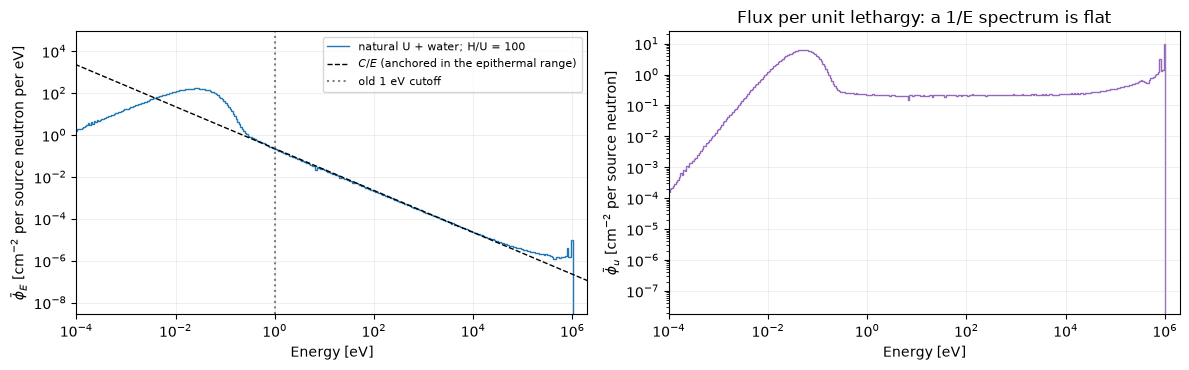

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].stairs(reference["phi_E"], ENERGY_EDGES, label="natural U + water; H/U = 100")
epithermal = (ENERGY >= 1e3) & (ENERGY <= 1e4) & (reference["phi_E"] > 0)
C = np.median(ENERGY[epithermal] * reference["phi_E"][epithermal])
axes[0].plot(ENERGY, C / ENERGY, "k--", lw=1, label=r"$C/E$ (anchored in the epithermal range)")
axes[0].set(xscale="log", yscale="log", xlim=(1e-4, 2e6),
            xlabel="Energy [eV]", ylabel=r"$\bar\phi_E$ [cm$^{-2}$ per source neutron per eV]")
axes[0].axvline(1.0, color="gray", ls=":", label="old 1 eV cutoff")
axes[0].legend(fontsize=8)
axes[1].stairs(reference["phi_u"], ENERGY_EDGES, color="tab:purple")
axes[1].set(xscale="log", yscale="log", xlim=(1e-4, 2e6),
            xlabel="Energy [eV]", ylabel=r"$\bar\phi_u$ [cm$^{-2}$ per source neutron]")
axes[1].set_title("Flux per unit lethargy: a 1/E spectrum is flat")
fig.tight_layout()
plt.show()

**Pause and predict.** What appears below the old 1 eV cutoff? Where are the
uranium resonance depressions? Why does a $1/E$ spectrum become approximately
flat when plotted per unit lethargy?

## 4. Thermal balance, detailed balance, and the correct Maxwellian

For thermal energies, the infinite-medium balance can be written schematically as

$$\Sigma_t(E)\phi(E)=\int_{\rm thermal}\Sigma_s(E'\!\to E)\phi(E')\,dE'
  +q_{\rm into\ thermal}(E).$$

The scattering kernel includes both downscatter and **upscatter**. At thermal
equilibrium, detailed balance makes the equilibrium-weighted forward and
reverse scattering flows equal. Ignoring absorption and the imposed source,
this leads to the Maxwell–Boltzmann equilibrium shape.

For the energy-transfer kernel, detailed balance is expressed as

$$\Sigma_s(E'\!\to E)\phi_{\rm MB}(E')
  =\Sigma_s(E\!\to E')\phi_{\rm MB}(E).$$

Be precise about the quantity: neutron **number density** per unit energy is
$n(E)\propto\sqrt E\,e^{-E/(k_BT)}$, but scalar **flux** is $v(E)n(E)$, so

$$\phi_{\rm MB}(E)\propto E\,e^{-E/(k_BT)}.$$

Its peak is at $E=k_BT$ (about 0.0253 eV at 294 K). An absorbing,
externally driven medium need not be exactly Maxwellian. Absorption, bound-atom
scattering, and the continuing supply of slowing-down neutrons distort it.

## 5. Controlled comparisons: binding, temperature, and absorption

The no-$S(\alpha,\beta)$ case is the **free-gas** comparison. It still has
thermal motion; it is not a model in which neutrons can only lose energy.
The bound-water law also represents molecular binding and motions.

Compare pure water at two temperatures, the free-gas approximation at 294 K,
and uranium loading at the same temperature. The second temperature must be
supported by the local neutron **and thermal-scattering** libraries (600 K
is provided in the data used to execute this draft).

In [6]:
cases = {"U + water, H/U=100, 294 K": reference}
cases["water, bound H, 294 K"] = spectrum_case("water-bound-294", H_to_U=None, seed=11003)
cases["water, free gas, 294 K"] = spectrum_case("water-free-294", H_to_U=None, bound_hydrogen=False, seed=11005)
cases["water, bound H, 600 K"] = spectrum_case("water-bound-600", H_to_U=None, temperature=600.0, seed=11007)
cases["U + water, H/U=5, 294 K"] = spectrum_case("uranium-water-R5", H_to_U=5.0, seed=11009)
print("All five thermalization cases are complete.")

All five thermalization cases are complete.


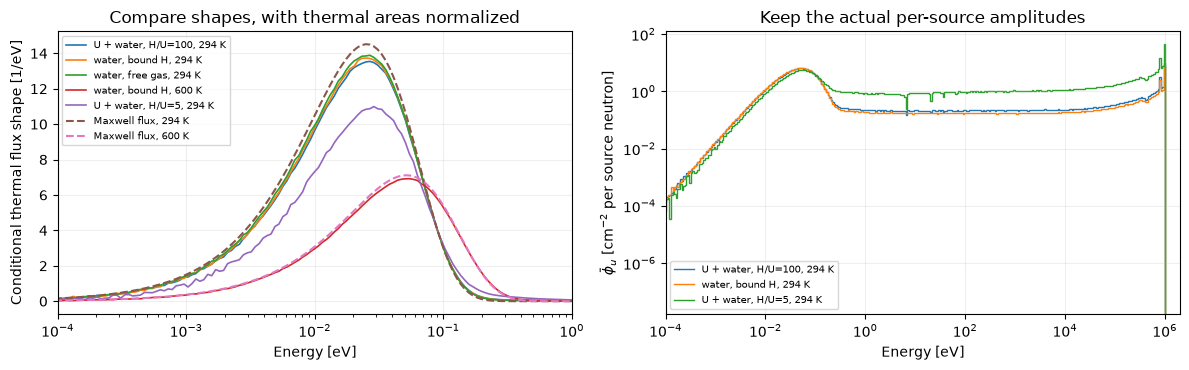

,thermal flux integral / source [cm^-2],fraction of tallied flux below 1 eV
case,,
"U + water, H/U=100, 294 K",12.30222,0.71537
"water, bound H, 294 K",12.45639,0.76031
"water, free gas, 294 K",12.38222,0.75946
"water, bound H, 600 K",17.43869,0.81577
"U + water, H/U=5, 294 K",11.97886,0.34620


In [7]:
thermal = ENERGY < 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
rows = []
for label, result in cases.items():
    # Conditional thermal shape: integral below 1 eV is one, not equal source strength.
    thermal_integral = result["bin_flux"][thermal].sum() / VOLUME
    normalized = result["phi_E"] / thermal_integral
    axes[0].plot(ENERGY[thermal], normalized[thermal], label=label, lw=1.2)
    if label.startswith("U +") or label == "water, bound H, 294 K":
        axes[1].stairs(result["phi_u"], ENERGY_EDGES, label=label)
    rows.append({"case": label,
                 "thermal flux integral / source [cm^-2]": thermal_integral,
                 "fraction of tallied flux below 1 eV": result["bin_flux"][thermal].sum() / result["bin_flux"].sum()})
for T in (294.0, 600.0):
    mb = ENERGY * np.exp(-ENERGY / (K_B * T))
    mb /= np.sum(mb[thermal] * DELTA_E[thermal])
    axes[0].plot(ENERGY[thermal], mb[thermal], "--", lw=1.5, label=f"Maxwell flux, {T:g} K")
axes[0].set(xscale="log", xlim=(1e-4, 1.0), xlabel="Energy [eV]",
            ylabel="Conditional thermal flux shape [1/eV]", title="Compare shapes, with thermal areas normalized")
axes[0].legend(fontsize=7)
axes[1].set(xscale="log", yscale="log", xlim=(1e-4, 2e6), xlabel="Energy [eV]",
            ylabel=r"$\bar\phi_u$ [cm$^{-2}$ per source neutron]", title="Keep the actual per-source amplitudes")
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()
display(pd.DataFrame(rows).set_index("case").round(5))

## 6. Checkpoints and bridge to Lesson 12

1. Use $k_BT$ to predict the thermal-flux peak at 294 K and 600 K. Does the
   simulated peak move as predicted? Explain departures from the ideal shape.
2. Explain why adding more absorber can harden the thermal spectrum. Compare
   H/U=100 with H/U=5 at the **same temperature** before comparing temperatures.
3. Why does matching the *area* of two thermal curves not imply equal thermal
   reaction rates or equal thermal-neutron populations per source?
4. What information is lost if you keep Lesson 10's 1 eV transport cutoff?
5. Increase `particles` and rerun one comparison. Identify a physical change
   versus a noisy tail; do not interpret empty/poorly sampled bins as exact zeros.

**Next:** a flux shape matters because reaction rates weight it by energy-dependent
cross sections. In Lesson 12 we add `nu-fission` and `absorption` scores, compute
effective macroscopic cross sections, and replace the imposed source by a
self-consistent fission source.